In [1]:
import os
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
input_file = "quantum_encoded_healthcare_data.xlsx"

if not os.path.exists(input_file):
    raise FileNotFoundError(
        f"File not found: {input_file}\n"
        f"Current folder: {os.getcwd()}"
    )

print("Input file found:")
print(os.path.abspath(input_file))

Input file found:
C:\Users\HOME\project-healthcare\notebooks\quantum_encoded_healthcare_data.xlsx


In [3]:
excel_file = pd.ExcelFile(input_file)

required_sheets = [
    "X_Train_Quantum",
    "X_Test_Quantum",
    "Y_Train",
    "Y_Test",
    "Class_Mapping"
]

missing_sheets = [
    sheet for sheet in required_sheets
    if sheet not in excel_file.sheet_names
]

if missing_sheets:
    raise ValueError(
        f"Missing sheets: {missing_sheets}"
    )

print("Available sheets:")

for sheet in excel_file.sheet_names:
    print("-", sheet)

print("\nAll required sheets are available.")

Available sheets:
- X_Train_Quantum
- X_Test_Quantum
- Y_Train
- Y_Test
- Class_Mapping
- Encoding_Quality
- PCA_Summary

All required sheets are available.


In [4]:
X_train_df = pd.read_excel(
    input_file,
    sheet_name="X_Train_Quantum"
)

X_test_df = pd.read_excel(
    input_file,
    sheet_name="X_Test_Quantum"
)

y_train_df = pd.read_excel(
    input_file,
    sheet_name="Y_Train"
)

y_test_df = pd.read_excel(
    input_file,
    sheet_name="Y_Test"
)

class_mapping = pd.read_excel(
    input_file,
    sheet_name="Class_Mapping"
)

X_train = X_train_df.to_numpy(dtype=float)
X_test = X_test_df.to_numpy(dtype=float)

y_train = y_train_df[
    "encoded_target"
].to_numpy(dtype=int)

y_test = y_test_df[
    "encoded_target"
].to_numpy(dtype=int)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Classes :", len(np.unique(y_train)))

X_train: (400, 4)
X_test : (100, 4)
y_train: (400,)
y_test : (100,)
Classes : 12


In [5]:
number_of_qubits = X_train.shape[1]

assert number_of_qubits == 4
assert X_test.shape[1] == number_of_qubits
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert not np.isnan(X_train).any()
assert not np.isnan(X_test).any()
assert not np.isinf(X_train).any()
assert not np.isinf(X_test).any()
assert len(np.unique(y_train)) == 12

print("Quantum-kernel input data verified.")

Quantum-kernel input data verified.


In [6]:
def balanced_sample_indices(
    labels,
    samples_per_class,
    random_state=42
):
    random_generator = np.random.default_rng(
        random_state
    )

    selected_indices = []

    for class_label in np.unique(labels):

        class_indices = np.where(
            labels == class_label
        )[0]

        sample_count = min(
            samples_per_class,
            len(class_indices)
        )

        chosen_indices = random_generator.choice(
            class_indices,
            size=sample_count,
            replace=False
        )

        selected_indices.extend(
            chosen_indices.tolist()
        )

    selected_indices = np.array(
        selected_indices,
        dtype=int
    )

    random_generator.shuffle(
        selected_indices
    )

    return selected_indices

In [7]:
train_samples_per_class = 8
test_samples_per_class = 3

train_indices = balanced_sample_indices(
    y_train,
    samples_per_class=train_samples_per_class,
    random_state=42
)

test_indices = balanced_sample_indices(
    y_test,
    samples_per_class=test_samples_per_class,
    random_state=42
)

X_train_kernel = X_train[train_indices]
y_train_kernel = y_train[train_indices]

X_test_kernel = X_test[test_indices]
y_test_kernel = y_test[test_indices]

print("Kernel training data:", X_train_kernel.shape)
print("Kernel testing data:", X_test_kernel.shape)

print("\nTraining class counts:")
print(
    pd.Series(y_train_kernel)
    .value_counts()
    .sort_index()
)

print("\nTesting class counts:")
print(
    pd.Series(y_test_kernel)
    .value_counts()
    .sort_index()
)

Kernel training data: (96, 4)
Kernel testing data: (36, 4)

Training class counts:
0     8
1     8
2     8
3     8
4     8
5     8
6     8
7     8
8     8
9     8
10    8
11    8
Name: count, dtype: int64

Testing class counts:
0     3
1     3
2     3
3     3
4     3
5     3
6     3
7     3
8     3
9     3
10    3
11    3
Name: count, dtype: int64


In [8]:
wires = list(range(number_of_qubits))

kernel_device = qml.device(
    "default.qubit",
    wires=number_of_qubits
)

iqp_repetitions = 2

entanglement_pattern = [
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 0]
]

print("Kernel quantum device created.")

Kernel quantum device created.


In [9]:
def iqp_feature_map(features):

    qml.IQPEmbedding(
        features=features,
        wires=wires,
        n_repeats=iqp_repetitions,
        pattern=entanglement_pattern
    )

In [10]:
@qml.qnode(kernel_device)
def quantum_kernel_circuit(
    first_features,
    second_features
):

    iqp_feature_map(first_features)

    qml.adjoint(
        iqp_feature_map
    )(second_features)

    return qml.probs(
        wires=wires
    )

In [11]:
def quantum_kernel(
    first_features,
    second_features
):
    probabilities = quantum_kernel_circuit(
        first_features,
        second_features
    )

    kernel_value = float(
        probabilities[0]
    )

    return np.clip(
        kernel_value,
        0.0,
        1.0
    )

In [12]:
self_similarity = quantum_kernel(
    X_train_kernel[0],
    X_train_kernel[0]
)

different_similarity = quantum_kernel(
    X_train_kernel[0],
    X_train_kernel[1]
)

print("Self-similarity:", self_similarity)
print("Different similarity:", different_similarity)

assert np.isclose(
    self_similarity,
    1.0,
    atol=1e-6
)

print("Quantum-kernel function verified.")

Self-similarity: 0.9999999999999973
Different similarity: 0.17887416867253478
Quantum-kernel function verified.


In [13]:
def create_symmetric_kernel_matrix(
    dataset
):
    number_of_records = len(dataset)

    matrix = np.eye(
        number_of_records,
        dtype=float
    )

    start_time = time.time()

    for row in range(number_of_records):

        for column in range(
            row + 1,
            number_of_records
        ):
            value = quantum_kernel(
                dataset[row],
                dataset[column]
            )

            matrix[row, column] = value
            matrix[column, row] = value

        if (
            (row + 1) % 10 == 0
            or row == number_of_records - 1
        ):
            print(
                f"Completed training row "
                f"{row + 1}/{number_of_records}"
            )

    elapsed_time = time.time() - start_time

    print(
        "Training kernel time:",
        round(elapsed_time, 2),
        "seconds"
    )

    return matrix, elapsed_time

In [14]:
def create_cross_kernel_matrix(
    test_dataset,
    train_dataset
):
    matrix = np.zeros(
        (
            len(test_dataset),
            len(train_dataset)
        ),
        dtype=float
    )

    start_time = time.time()

    for row in range(len(test_dataset)):

        for column in range(
            len(train_dataset)
        ):
            matrix[row, column] = quantum_kernel(
                test_dataset[row],
                train_dataset[column]
            )

        if (
            (row + 1) % 5 == 0
            or row == len(test_dataset) - 1
        ):
            print(
                f"Completed testing row "
                f"{row + 1}/{len(test_dataset)}"
            )

    elapsed_time = time.time() - start_time

    print(
        "Testing kernel time:",
        round(elapsed_time, 2),
        "seconds"
    )

    return matrix, elapsed_time

In [15]:
quantum_train_kernel, train_kernel_time = (
    create_symmetric_kernel_matrix(
        X_train_kernel
    )
)

print(
    "Training kernel shape:",
    quantum_train_kernel.shape
)

Completed training row 10/96
Completed training row 20/96
Completed training row 30/96
Completed training row 40/96
Completed training row 50/96
Completed training row 60/96
Completed training row 70/96
Completed training row 80/96
Completed training row 90/96
Completed training row 96/96
Training kernel time: 54.72 seconds
Training kernel shape: (96, 96)


In [16]:
quantum_test_kernel, test_kernel_time = (
    create_cross_kernel_matrix(
        X_test_kernel,
        X_train_kernel
    )
)

print(
    "Testing kernel shape:",
    quantum_test_kernel.shape
)

Completed testing row 5/36
Completed testing row 10/36
Completed testing row 15/36
Completed testing row 20/36
Completed testing row 25/36
Completed testing row 30/36
Completed testing row 35/36
Completed testing row 36/36
Testing kernel time: 43.78 seconds
Testing kernel shape: (36, 96)


In [17]:
kernel_symmetric = np.allclose(
    quantum_train_kernel,
    quantum_train_kernel.T,
    atol=1e-8
)

kernel_diagonal = np.diag(
    quantum_train_kernel
)

kernel_eigenvalues = np.linalg.eigvalsh(
    quantum_train_kernel
)

kernel_validation = pd.DataFrame({
    "check": [
        "Training kernel rows",
        "Training kernel columns",
        "Test kernel rows",
        "Test kernel columns",
        "Symmetric",
        "Minimum diagonal",
        "Maximum diagonal",
        "Minimum kernel value",
        "Maximum kernel value",
        "Minimum eigenvalue",
        "Maximum eigenvalue",
        "Training calculation seconds",
        "Testing calculation seconds"
    ],
    "result": [
        quantum_train_kernel.shape[0],
        quantum_train_kernel.shape[1],
        quantum_test_kernel.shape[0],
        quantum_test_kernel.shape[1],
        kernel_symmetric,
        kernel_diagonal.min(),
        kernel_diagonal.max(),
        quantum_train_kernel.min(),
        quantum_train_kernel.max(),
        kernel_eigenvalues.min(),
        kernel_eigenvalues.max(),
        train_kernel_time,
        test_kernel_time
    ]
})

display(kernel_validation)

,check,result
0,Training kernel rows,96
1,Training kernel columns,96
2,Test kernel rows,36
3,Test kernel columns,96
4,Symmetric,True
5,Minimum diagonal,1.0
6,Maximum diagonal,1.0
7,Minimum kernel value,0.000013
8,Maximum kernel value,1.0
9,Minimum eigenvalue,0.000191


In [18]:
assert quantum_train_kernel.shape == (
    len(X_train_kernel),
    len(X_train_kernel)
)

assert quantum_test_kernel.shape == (
    len(X_test_kernel),
    len(X_train_kernel)
)

assert kernel_symmetric

assert np.allclose(
    kernel_diagonal,
    1.0,
    atol=1e-6
)

assert quantum_train_kernel.min() >= -1e-10

assert quantum_train_kernel.max() <= 1.0 + 1e-10

assert kernel_eigenvalues.min() >= -1e-8

print("Quantum-kernel validation passed.")

Quantum-kernel validation passed.


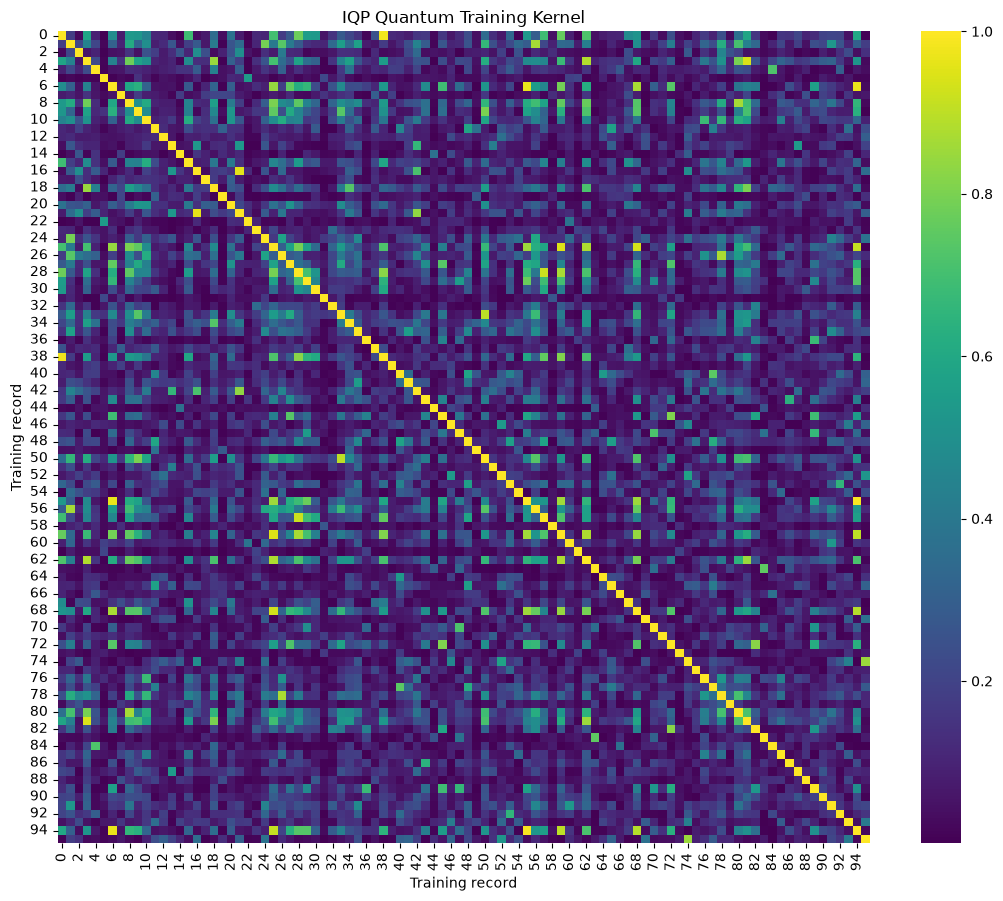

In [19]:
plt.figure(figsize=(11, 9))

sns.heatmap(
    quantum_train_kernel,
    cmap="viridis",
    square=True
)

plt.title("IQP Quantum Training Kernel")
plt.xlabel("Training record")
plt.ylabel("Training record")

plt.tight_layout()
plt.show()

In [20]:
quantum_kernel_model = SVC(
    kernel="precomputed",
    C=1.0,
    class_weight="balanced",
    probability=True,
    random_state=42
)

quantum_kernel_model.fit(
    quantum_train_kernel,
    y_train_kernel
)

print("Quantum-kernel SVM trained successfully.")

Quantum-kernel SVM trained successfully.


C:\Users\HOME\anaconda3\envs\healthcare-qml\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [21]:
y_pred = quantum_kernel_model.predict(
    quantum_test_kernel
)

y_probability = (
    quantum_kernel_model.predict_proba(
        quantum_test_kernel
    )
)

print("Predictions generated:", len(y_pred))

Predictions generated: 36


In [22]:
accuracy = accuracy_score(
    y_test_kernel,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_test_kernel,
    y_pred
)

macro_f1 = f1_score(
    y_test_kernel,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test_kernel,
    y_pred,
    average="weighted",
    zero_division=0
)

evaluation_results = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1-score",
        "Weighted F1-score"
    ],
    "score": [
        accuracy,
        balanced_accuracy,
        macro_f1,
        weighted_f1
    ]
})

evaluation_results["score"] = (
    evaluation_results["score"].round(4)
)

display(evaluation_results)

,metric,score
0,Accuracy,0.2222
1,Balanced Accuracy,0.2222
2,Macro F1-score,0.2044
3,Weighted F1-score,0.2044


In [23]:
class_names = (
    class_mapping
    .sort_values("encoded_label")[
        "historical_medication_class"
    ]
    .tolist()
)

classification_results = pd.DataFrame(
    classification_report(
        y_test_kernel,
        y_pred,
        labels=np.arange(
            len(class_names)
        ),
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
).transpose()

display(
    classification_results.round(4)
)

,precision,recall,f1-score,support
Acid-suppression class A,0.0000,0.0000,0.0000,3.0000
Acid-suppression class B,0.0000,0.0000,0.0000,3.0000
Antidiabetic class A,0.0000,0.0000,0.0000,3.0000
Antidiabetic class B,0.5000,0.3333,0.4000,3.0000
Antihistamine class A,0.0000,0.0000,0.0000,3.0000
Antihistamine class B,0.0000,0.0000,0.0000,3.0000
Antihypertensive class A,0.0000,0.0000,0.0000,3.0000
Antihypertensive class B,0.6667,0.6667,0.6667,3.0000
Bronchodilator class,0.2500,0.3333,0.2857,3.0000
Controller inhaler class,0.0000,0.0000,0.0000,3.0000


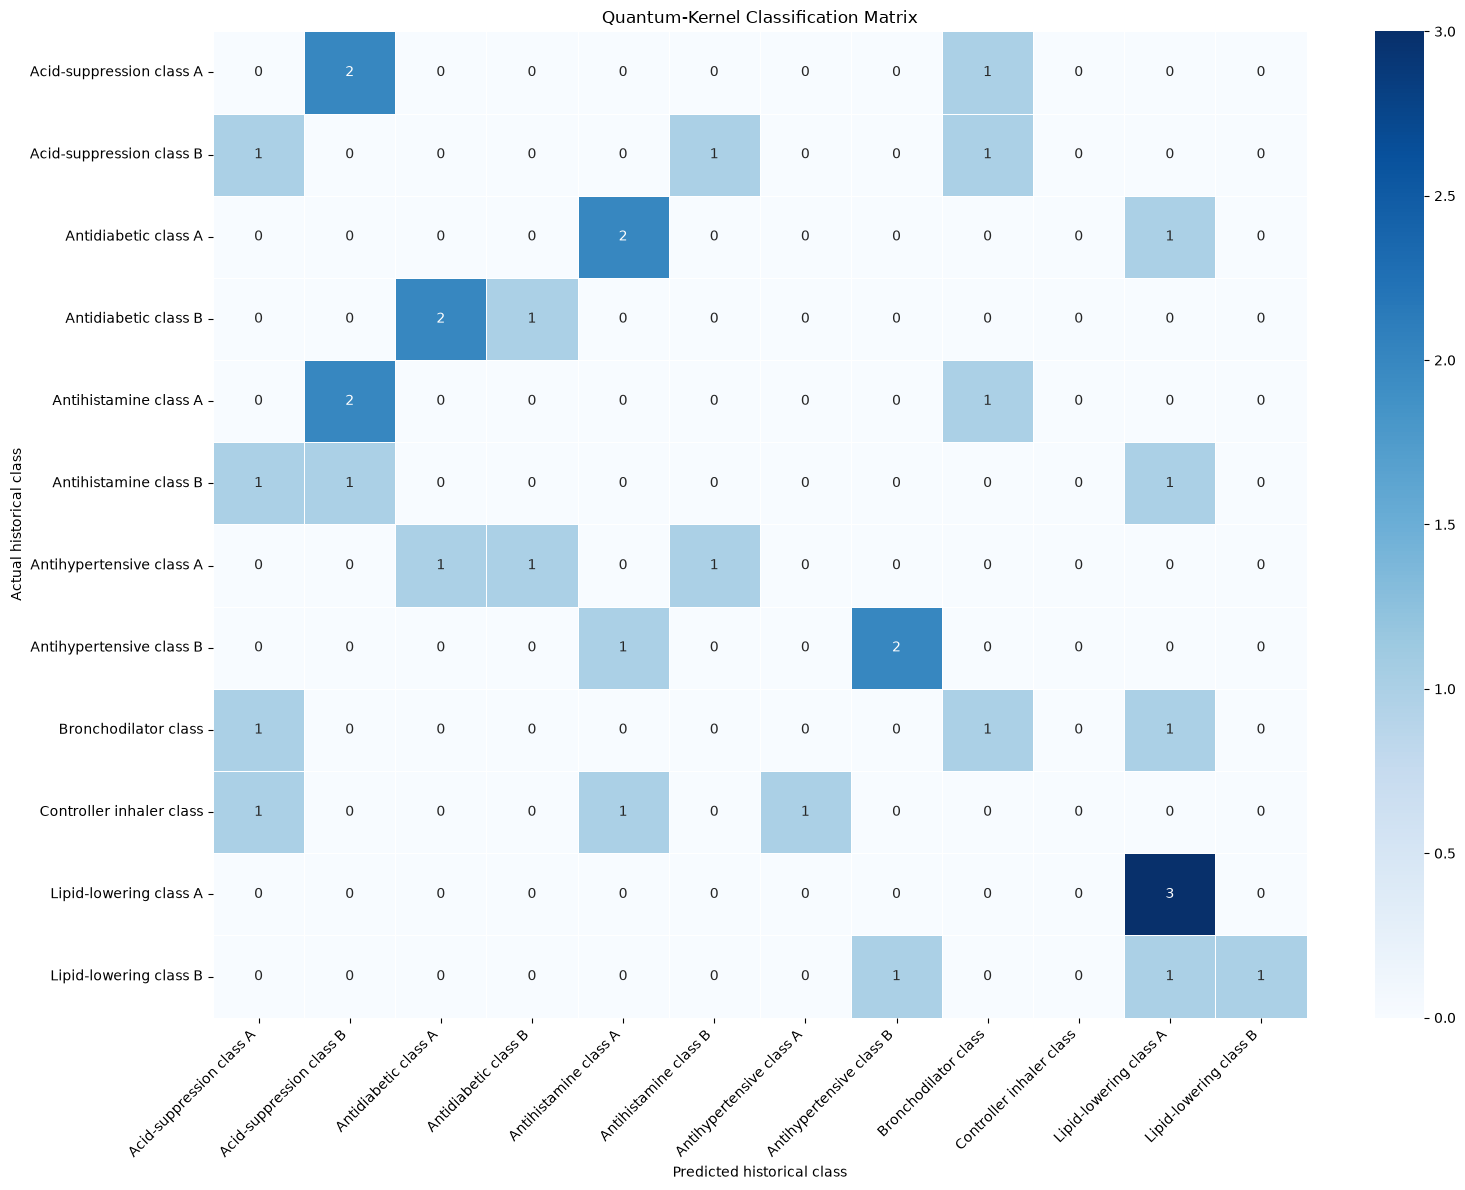

In [24]:
confusion = confusion_matrix(
    y_test_kernel,
    y_pred,
    labels=np.arange(
        len(class_names)
    )
)

confusion_df = pd.DataFrame(
    confusion,
    index=class_names,
    columns=class_names
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    confusion_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Quantum-Kernel Classification Matrix")
plt.xlabel("Predicted historical class")
plt.ylabel("Actual historical class")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [25]:
prediction_results = pd.DataFrame({
    "test_subset_index":
        test_indices,
    "actual_encoded_class":
        y_test_kernel,
    "predicted_encoded_class":
        y_pred,
    "correct_prediction":
        y_test_kernel == y_pred,
    "prediction_confidence":
        y_probability.max(axis=1)
})

label_lookup = class_mapping.set_index(
    "encoded_label"
)[
    "historical_medication_class"
].to_dict()

prediction_results[
    "actual_historical_class"
] = prediction_results[
    "actual_encoded_class"
].map(label_lookup)

prediction_results[
    "predicted_historical_class"
] = prediction_results[
    "predicted_encoded_class"
].map(label_lookup)

display(prediction_results.head(10))

,test_subset_index,actual_encoded_class,predicted_encoded_class,correct_prediction,prediction_confidence,actual_historical_class,predicted_historical_class
0,47,11,11,True,0.109878,Lipid-lowering class B,Lipid-lowering class B
1,3,10,10,True,0.110787,Lipid-lowering class A,Lipid-lowering class A
2,23,11,10,False,0.114733,Lipid-lowering class B,Lipid-lowering class A
3,73,9,4,False,0.112730,Controller inhaler class,Antihistamine class A
4,6,7,4,False,0.100192,Antihypertensive class B,Antihistamine class A
5,45,8,8,True,0.110863,Bronchodilator class,Bronchodilator class
6,83,0,1,False,0.148120,Acid-suppression class A,Acid-suppression class B
7,50,2,4,False,0.093187,Antidiabetic class A,Antihistamine class A
8,72,8,10,False,0.107550,Bronchodilator class,Lipid-lowering class A
9,22,11,7,False,0.124247,Lipid-lowering class B,Antihypertensive class B


In [26]:
output_file = "quantum_kernel_development_results.xlsx"

train_kernel_df = pd.DataFrame(
    quantum_train_kernel,
    index=[
        f"train_{index}"
        for index in train_indices
    ],
    columns=[
        f"train_{index}"
        for index in train_indices
    ]
)

test_kernel_df = pd.DataFrame(
    quantum_test_kernel,
    index=[
        f"test_{index}"
        for index in test_indices
    ],
    columns=[
        f"train_{index}"
        for index in train_indices
    ]
)

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    train_kernel_df.to_excel(
        writer,
        sheet_name="Train_Kernel"
    )

    test_kernel_df.to_excel(
        writer,
        sheet_name="Test_Kernel"
    )

    kernel_validation.to_excel(
        writer,
        sheet_name="Kernel_Validation",
        index=False
    )

    evaluation_results.to_excel(
        writer,
        sheet_name="Evaluation",
        index=False
    )

    classification_results.to_excel(
        writer,
        sheet_name="Classification_Report"
    )

    confusion_df.to_excel(
        writer,
        sheet_name="Confusion_Matrix"
    )

    prediction_results.to_excel(
        writer,
        sheet_name="Predictions",
        index=False
    )

    pd.DataFrame({
        "train_indices": pd.Series(
            train_indices
        ),
        "test_indices": pd.Series(
            test_indices
        )
    }).to_excel(
        writer,
        sheet_name="Subset_Indices",
        index=False
    )

print("Results saved:")
print(os.path.abspath(output_file))

Results saved:
C:\Users\HOME\project-healthcare\notebooks\quantum_kernel_development_results.xlsx


In [27]:
model_file = "quantum_kernel_svm.pkl"

joblib.dump(
    quantum_kernel_model,
    model_file
)

kernel_configuration = {
    "feature_map":
        "IQPEmbedding",
    "number_of_qubits":
        number_of_qubits,
    "iqp_repetitions":
        iqp_repetitions,
    "entanglement_pattern":
        entanglement_pattern,
    "train_samples_per_class":
        train_samples_per_class,
    "test_samples_per_class":
        test_samples_per_class,
    "training_subset_size":
        len(X_train_kernel),
    "testing_subset_size":
        len(X_test_kernel),
    "svc_C":
        1.0,
    "class_weight":
        "balanced"
}

configuration_file = (
    "quantum_kernel_configuration.json"
)

with open(
    configuration_file,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        kernel_configuration,
        file,
        indent=4
    )

print("Model saved:", os.path.abspath(model_file))
print(
    "Configuration saved:",
    os.path.abspath(configuration_file)
)

Model saved: C:\Users\HOME\project-healthcare\notebooks\quantum_kernel_svm.pkl
Configuration saved: C:\Users\HOME\project-healthcare\notebooks\quantum_kernel_configuration.json


In [28]:
saved_results = pd.ExcelFile(
    output_file
)

print("Saved sheets:")

for sheet in saved_results.sheet_names:
    print("-", sheet)

assert os.path.exists(model_file)
assert os.path.exists(configuration_file)
assert quantum_train_kernel.shape == (96, 96)
assert quantum_test_kernel.shape == (36, 96)

print("=" * 60)
print("QUANTUM KERNEL DEVELOPMENT COMPLETED")
print("=" * 60)

print("Training kernel:", quantum_train_kernel.shape)
print("Testing kernel:", quantum_test_kernel.shape)
print("Accuracy:", round(accuracy, 4))
print("Macro F1-score:", round(macro_f1, 4))

Saved sheets:
- Train_Kernel
- Test_Kernel
- Kernel_Validation
- Evaluation
- Classification_Report
- Confusion_Matrix
- Predictions
- Subset_Indices
QUANTUM KERNEL DEVELOPMENT COMPLETED
Training kernel: (96, 96)
Testing kernel: (36, 96)
Accuracy: 0.2222
Macro F1-score: 0.2044
